# Part C — Machine Learning Models for Prepayment

(i)   Build predictive ML models for prepayment: regularized logistic, random forest, LightGBM, XGBoost.
(ii)  Compare predictive performance with the Cox model (predictions provided by Part B teammate).
(iii) Backtest on out-of-sample vintages with a short horizon.

**Splits (loan-level, no panel):**
- Train: vintages 2006–2013, 60-month prepay label, 2M sampled loans
- Test:  vintages 2014–2017, 60-month prepay label, full size
- Backtest A: vintages 2019–2020, **24-month** prepay label (data cutoff caps observation)
- Backtest B: vintage 2024, **12-month** prepay label (high-rate regime; 2023 dropped due to partial coverage)

**Features (extended team set):** Part B's static features + macro-at-origination + 7 additional
loan-level features adopted from the Deep Cox teammate (state, occupancy, orig_upb,
first_time_homebuyer, prop_type, mi_pct, n_units). Same set used by Classical Cox and Deep Cox
for apples-to-apples comparison.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

import gc
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.credit_data import load_loans, load_macro

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
pd.set_option("display.max_columns", 60)

print("repo:", REPO_ROOT)
print("figures →", FIGURES_DIR)

repo: c:\Users\loren\Desktop\IR Project\freddie-credit-30y-frm
figures → c:\Users\loren\Desktop\IR Project\freddie-credit-30y-frm\figures


In [2]:
# Cell 3

# ── Splits ──────────────────────────────────────────────────────────────────
TRAIN_YEARS      = list(range(2006, 2014))   # 2006-2013
TEST_YEARS       = list(range(2014, 2018))   # 2014-2017
BACKTEST_A_YEARS = [2019, 2020]
BACKTEST_B_YEARS = [2024]                    # 2023 dropped (partial-data contamination)

HORIZON_MAIN       = 60
HORIZON_BACKTEST_A = 24
HORIZON_BACKTEST_B = 12

TRAIN_SAMPLE = 2_000_000
RANDOM_SEED  = 42

# ── Features (extended team set: Part B + 7 from Arsh's feature list) ───────
STATIC_FEATURES = [
    # Part B original 8
    "fico", "ltv", "dti", "orig_rate",
    "loan_purpose", "channel", "n_borrowers", "vintage_year",
    # Extended set
    "state",                # geographic variation in HPI / turnover
    "occupancy",            # owner vs second-home vs investor
    "orig_upb",             # loan size scales refi incentive
    "first_time_homebuyer", # FTHB behavioral effect
    "prop_type",            # SFH / condo / PUD / manufactured
    "mi_pct",               # MI removal incentive
    "n_units",              # 1-unit vs 2-4 (investor)
]
MACRO_COLS = ["MORTGAGE30US", "GS10", "UNRATE", "CPIAUCSL", "CSUSHPISA"]

DURATION_COL = "event_time_months"
EVENT_COL    = "prepay_observed"

In [3]:
#cell 4

def load_with_macro(years: list[int], sample: int | None = None) -> pd.DataFrame:
    """
    Load origination + outcome + macro-at-origination with the same derived
    features as scripts/partB_cox.py. Returns a pandas DataFrame.

    `loan_seq_num` is kept (we need it later to join Cox predictions).
    Set sample=None to load all rows (use for test/backtest sets).
    """
    cols = (
        ["loan_seq_num", DURATION_COL, "event_type", "first_payment_date"]
        + STATIC_FEATURES
    )
    loans = (
        load_loans(years=years, columns=cols)
        .with_columns(
            (pl.col("event_type") == "prepaid").cast(pl.Int8).alias(EVENT_COL)
        )
        .filter(
            pl.col(DURATION_COL).is_not_null()
            & (pl.col(DURATION_COL) > 0)
        )
        .drop("event_type")
    )

    mac = load_macro().with_columns(pl.col("month").cast(pl.Date))

    loans = (
        loans
        .join(mac.select(["month"] + MACRO_COLS),
              left_on="first_payment_date", right_on="month", how="left")
        .with_columns([
            # Rate incentive at origination: loan rate minus prevailing market rate.
            (pl.col("orig_rate") - pl.col("MORTGAGE30US")).alias("rate_incentive_orig"),
            # Mortgage-Treasury spread (risk premium proxy).
            (pl.col("MORTGAGE30US") - pl.col("GS10")).alias("mort_treasury_spread"),
            # HPI/CPI are levels — log so coefficients scale naturally.
            pl.col("CSUSHPISA").log().alias("log_hpi"),
            pl.col("CPIAUCSL").log().alias("log_cpi"),
        ])
        .drop(["first_payment_date", "MORTGAGE30US", "CSUSHPISA", "CPIAUCSL"])
    )

    if sample is not None and loans.height > sample:
        loans = loans.sample(n=sample, seed=RANDOM_SEED)

    print(f"  loaded {loans.height:,} loans "
          f"({int(loans[EVENT_COL].sum()):,} prepayments observed)")
    return loans.to_pandas()

In [4]:
#cell 5

print("=" * 60); print(f"Train: {TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]}"); print("=" * 60)
train_raw      = load_with_macro(TRAIN_YEARS, sample=TRAIN_SAMPLE)

print("\n" + "=" * 60); print(f"Test: {TEST_YEARS[0]}–{TEST_YEARS[-1]}"); print("=" * 60)
test_raw       = load_with_macro(TEST_YEARS, sample=None)

print("\n" + "=" * 60); print(f"Backtest A: {BACKTEST_A_YEARS}"); print("=" * 60)
backtest_a_raw = load_with_macro(BACKTEST_A_YEARS, sample=None)

print("\n" + "=" * 60); print(f"Backtest B: {BACKTEST_B_YEARS}"); print("=" * 60)
backtest_b_raw = load_with_macro(BACKTEST_B_YEARS, sample=None)

gc.collect()

Train: 2006–2013
  loaded 2,000,000 loans (1,669,318 prepayments observed)

Test: 2014–2017
  loaded 4,266,221 loans (3,128,321 prepayments observed)

Backtest A: [2019, 2020]
  loaded 4,301,126 loans (1,741,970 prepayments observed)

Backtest B: [2024]
  loaded 968,920 loans (81,997 prepayments observed)


1516

In [5]:
#cell 6

def build_label_and_filter(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """As before — see explanation in earlier cell."""
    prepay_in_window = (df[EVENT_COL] == 1) & (df[DURATION_COL] <= horizon)
    observed_full    = df[DURATION_COL] >= horizon

    label = pd.Series(np.nan, index=df.index)
    label[prepay_in_window]                   = 1.0
    label[observed_full & ~prepay_in_window]  = 0.0

    keep = label.notna()
    out  = df.loc[keep].copy()
    out[f"y_prepay_{horizon}m"] = label[keep].astype("int8")
    print(f"  horizon={horizon}mo: kept {len(out):,} / {len(df):,} "
          f"({len(out)/len(df):.1%}; rate = {out[f'y_prepay_{horizon}m'].mean():.3f})")
    return out

print("Building labels ...")
train      = build_label_and_filter(train_raw,      horizon=HORIZON_MAIN)
test       = build_label_and_filter(test_raw,       horizon=HORIZON_MAIN)
backtest_a = build_label_and_filter(backtest_a_raw, horizon=HORIZON_BACKTEST_A)
backtest_b = build_label_and_filter(backtest_b_raw, horizon=HORIZON_BACKTEST_B)

del train_raw, test_raw, backtest_a_raw, backtest_b_raw
gc.collect()

Building labels ...
  horizon=60mo: kept 1,951,750 / 2,000,000 (97.6%; rate = 0.541)
  horizon=60mo: kept 4,199,495 / 4,266,221 (98.4%; rate = 0.577)
  horizon=24mo: kept 4,276,019 / 4,301,126 (99.4%; rate = 0.339)
  horizon=12mo: kept 637,366 / 968,920 (65.8%; rate = 0.101)


0

In [6]:
#cell 7

LABEL_MAIN = f"y_prepay_{HORIZON_MAIN}m"
LABEL_BT_A = f"y_prepay_{HORIZON_BACKTEST_A}m"
LABEL_BT_B = f"y_prepay_{HORIZON_BACKTEST_B}m"

print("=" * 70)
print("Split summary")
print("=" * 70)
for name, df, lbl in [
    ("Train      (60mo)", train,      LABEL_MAIN),
    ("Test       (60mo)", test,       LABEL_MAIN),
    ("Backtest A (24mo)", backtest_a, LABEL_BT_A),
    ("Backtest B (12mo)", backtest_b, LABEL_BT_B),
]:
    print(f"{name}:  n={len(df):>10,}   "
          f"positives={int(df[lbl].sum()):>9,}   "
          f"rate={df[lbl].mean():.3f}   "
          f"vintages={sorted(df['vintage_year'].unique().tolist())}")

print("\n" + "=" * 70); print("Positive rate by vintage"); print("=" * 70)
for name, df, lbl in [("Train", train, LABEL_MAIN), ("Test", test, LABEL_MAIN),
                       ("Backtest A", backtest_a, LABEL_BT_A),
                       ("Backtest B", backtest_b, LABEL_BT_B)]:
    rates = (df.groupby("vintage_year")[lbl].agg(n="count", prepay_rate="mean"))
    print(f"\n{name}:"); print(rates.to_string(float_format=lambda x: f"{x:.3f}"))

# Feature columns check (now over 4 splits)
non_feature = {"loan_seq_num", DURATION_COL, EVENT_COL, LABEL_MAIN, LABEL_BT_A, LABEL_BT_B}
feat_sets = [set(df.columns) - non_feature for df in [train, test, backtest_a, backtest_b]]
common = set.intersection(*feat_sets)
all_   = set.union(*feat_sets)
print(f"\n{len(common)} shared feature columns" + 
      (f" (mismatch: {sorted(all_ - common)})" if all_ != common else " ✓"))

Split summary
Train      (60mo):  n= 1,951,750   positives=1,055,229   rate=0.541   vintages=[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013]
Test       (60mo):  n= 4,199,495   positives=2,423,069   rate=0.577   vintages=[2014, 2015, 2016, 2017]
Backtest A (24mo):  n= 4,276,019   positives=1,447,450   rate=0.339   vintages=[2019, 2020]
Backtest B (12mo):  n=   637,366   positives=   64,107   rate=0.101   vintages=[2024]

Positive rate by vintage

Train:
                   n  prepay_rate
vintage_year                     
2006          210150        0.573
2007          218473        0.603
2008          213505        0.747
2009          370843        0.635
2010          246465        0.540
2011          171796        0.524
2012          264340        0.339
2013          256178        0.373

Test:
                    n  prepay_rate
vintage_year                      
2014           842575        0.494
2015          1068187        0.477
2016          1229812        0.600
2017          105892

## Preprocessing — X / y matrices

One-hot encode `loan_purpose` and `channel` (matching Part B's encoding —
drop_first=True). Other features stay numeric. Standardize numeric features
fit on train (only matters for logistic regression; trees are scale-invariant
but it doesn't hurt).

In [7]:
# Cell 9
from sklearn.preprocessing import StandardScaler

LABEL_MAIN = f"y_prepay_{HORIZON_MAIN}m"
LABEL_BT_A = f"y_prepay_{HORIZON_BACKTEST_A}m"
LABEL_BT_B = f"y_prepay_{HORIZON_BACKTEST_B}m"

# Concatenate splits, one-hot encode consistently, split back.
splits = [
    ("train",      train,      LABEL_MAIN),
    ("test",       test,       LABEL_MAIN),
    ("backtest_a", backtest_a, LABEL_BT_A),
    ("backtest_b", backtest_b, LABEL_BT_B),
]
frames = []
for name, df, lbl in splits:
    f = df.copy()
    f["__split__"] = name
    f["__label__"] = f[lbl].astype("int8")
    f = f.drop(columns=[c for c in [LABEL_MAIN, LABEL_BT_A, LABEL_BT_B] if c in f.columns])
    frames.append(f)
combined = pd.concat(frames, ignore_index=False)

# One-hot — drop_first=True to match Part B
cat_cols = ["loan_purpose", "channel", "state", "occupancy", "first_time_homebuyer", "prop_type"]
combined_oh = pd.get_dummies(combined, columns=cat_cols, drop_first=True, dtype=float)

# Define feature columns (everything except labels / IDs / split tag)
non_feature = {"loan_seq_num", DURATION_COL, EVENT_COL, "__split__", "__label__"}
feature_cols = sorted(c for c in combined_oh.columns if c not in non_feature)

# Drop rows with NaN in features (rare — macro join misses)
before = len(combined_oh)
combined_oh = combined_oh.dropna(subset=feature_cols)
print(f"Dropped {before - len(combined_oh):,} rows with feature NaNs "
      f"({(before - len(combined_oh))/before:.2%})")

# Split back into four (X, y, loan_seq_num) tuples
def _split_out(df_oh, name):
    sub = df_oh[df_oh["__split__"] == name]
    X   = sub[feature_cols].to_numpy().astype("float32")
    y   = sub["__label__"].to_numpy().astype("int8")
    ids = sub["loan_seq_num"].to_numpy()
    return X, y, ids

X_tr, y_tr, id_tr = _split_out(combined_oh, "train")
X_te, y_te, id_te = _split_out(combined_oh, "test")
X_a,  y_a,  id_a  = _split_out(combined_oh, "backtest_a")
X_b,  y_b,  id_b  = _split_out(combined_oh, "backtest_b")

# Standardize (fit on train only)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr).astype("float32")
X_te_s = scaler.transform(X_te).astype("float32")
X_a_s  = scaler.transform(X_a ).astype("float32")
X_b_s  = scaler.transform(X_b ).astype("float32")

del combined, combined_oh, frames
gc.collect()

print(f"\n{len(feature_cols)} features after one-hot:")
for c in feature_cols:
    print(f"  {c}")

print(f"\nShapes:")
print(f"  train      X={X_tr.shape}   y_pos={y_tr.mean():.3f}")
print(f"  test       X={X_te.shape}   y_pos={y_te.mean():.3f}")
print(f"  backtest_a X={X_a.shape}    y_pos={y_a.mean():.3f}")
print(f"  backtest_b X={X_b.shape}    y_pos={y_b.mean():.3f}")

Dropped 529,228 rows with feature NaNs (4.78%)

80 features after one-hot:
  GS10
  UNRATE
  channel_C
  channel_R
  channel_T
  dti
  fico
  first_time_homebuyer_Y
  loan_purpose_N
  loan_purpose_P
  log_cpi
  log_hpi
  ltv
  mi_pct
  mort_treasury_spread
  n_borrowers
  n_units
  occupancy_P
  occupancy_S
  orig_rate
  orig_upb
  prop_type_CP
  prop_type_MH
  prop_type_PU
  prop_type_SF
  rate_incentive_orig
  state_AL
  state_AR
  state_AZ
  state_CA
  state_CO
  state_CT
  state_DC
  state_DE
  state_FL
  state_GA
  state_GU
  state_HI
  state_IA
  state_ID
  state_IL
  state_IN
  state_KS
  state_KY
  state_LA
  state_MA
  state_MD
  state_ME
  state_MI
  state_MN
  state_MO
  state_MS
  state_MT
  state_NC
  state_ND
  state_NE
  state_NH
  state_NJ
  state_NM
  state_NV
  state_NY
  state_OH
  state_OK
  state_OR
  state_PA
  state_PR
  state_RI
  state_SC
  state_SD
  state_TN
  state_TX
  state_UT
  state_VA
  state_VI
  state_VT
  state_WA
  state_WI
  state_WV
  state_WY
  v

## Model 1 — L1-Regularized Logistic Regression

The "regularized regression" arm of Part C(i). Linear baseline; gives a sparse
coefficient table you can compare directly against Part B's Cox hazard ratios
(both are log-linear in the standardized features, so signs and rough magnitudes
should agree).

In [8]:
# Cell 11
from sklearn.linear_model import LogisticRegression
import time

print("Fitting L1 logistic regression ...")
t0 = time.time()


lr_l1 = LogisticRegression(
    l1_ratio=1.0,        # 1.0 = pure L1, 0.0 = pure L2
    solver="saga",
    C=1.0,
    max_iter=300,
    random_state=RANDOM_SEED,
).fit(X_tr_s, y_tr)
print(f"  done in {time.time() - t0:.1f}s")

# Coefficient table (standardized scale — directly comparable across features)
coefs = pd.Series(lr_l1.coef_[0], index=feature_cols)
coef_df = (
    pd.DataFrame({
        "coef_std":     coefs,
        "abs_coef_std": coefs.abs(),
        "odds_ratio":   np.exp(coefs),
    })
    .sort_values("abs_coef_std", ascending=False)
)
print("\nCoefficients (standardized scale, sorted by |magnitude|):")
print(coef_df.to_string(float_format=lambda x: f"{x:+.4f}"))

n_nonzero = (coefs.abs() > 1e-8).sum()
print(f"\nNon-zero coefficients: {n_nonzero} / {len(feature_cols)}")

Fitting L1 logistic regression ...
  done in 45.5s

Coefficients (standardized scale, sorted by |magnitude|):
                        coef_std  abs_coef_std  odds_ratio
orig_rate                +0.5664       +0.5664     +1.7619
orig_upb                 +0.4555       +0.4555     +1.5769
GS10                     +0.4318       +0.4318     +1.5400
UNRATE                   +0.3637       +0.3637     +1.4386
mort_treasury_spread     +0.3372       +0.3372     +1.4010
fico                     +0.2484       +0.2484     +1.2820
ltv                      -0.2171       +0.2171     +0.8049
vintage_year             +0.1904       +0.1904     +1.2098
loan_purpose_P           +0.1877       +0.1877     +1.2065
occupancy_P              +0.1857       +0.1857     +1.2041
state_FL                 -0.1507       +0.1507     +0.8601
prop_type_PU             +0.1243       +0.1243     +1.1323
state_NY                 -0.1111       +0.1111     +0.8948
rate_incentive_orig      +0.0963       +0.0963     +1.1011
state

In [9]:
# Cell 12
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score

def evaluate(model, X, y):
    p = model.predict_proba(X)[:, 1]
    return p, dict(
        n         = len(y),
        pos_rate  = float(y.mean()),
        auc       = roc_auc_score(y, p),
        ap        = average_precision_score(y, p),
        brier     = brier_score_loss(y, p),
    )

eval_sets = [
    ("train",      X_tr_s, y_tr),
    ("test",       X_te_s, y_te),
    ("backtest_a", X_a_s,  y_a),
    ("backtest_b", X_b_s,  y_b),
]

preds_l1 = {}
rows = []
for name, X, y in eval_sets:
    p, m = evaluate(lr_l1, X, y)
    preds_l1[name] = p
    rows.append({"split": name, **m})

l1_metrics = pd.DataFrame(rows).set_index("split")
print(l1_metrics.to_string(
    float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

                  n  pos_rate    auc     ap  brier
split                                             
train       1619078    0.5711 0.7213 0.7741 0.2107
test        4004821    0.5853 0.5891 0.6635 0.2929
backtest_a  4274356    0.3385 0.6211 0.4431 0.2388
backtest_b   637147    0.1006 0.6323 0.1728 0.8194


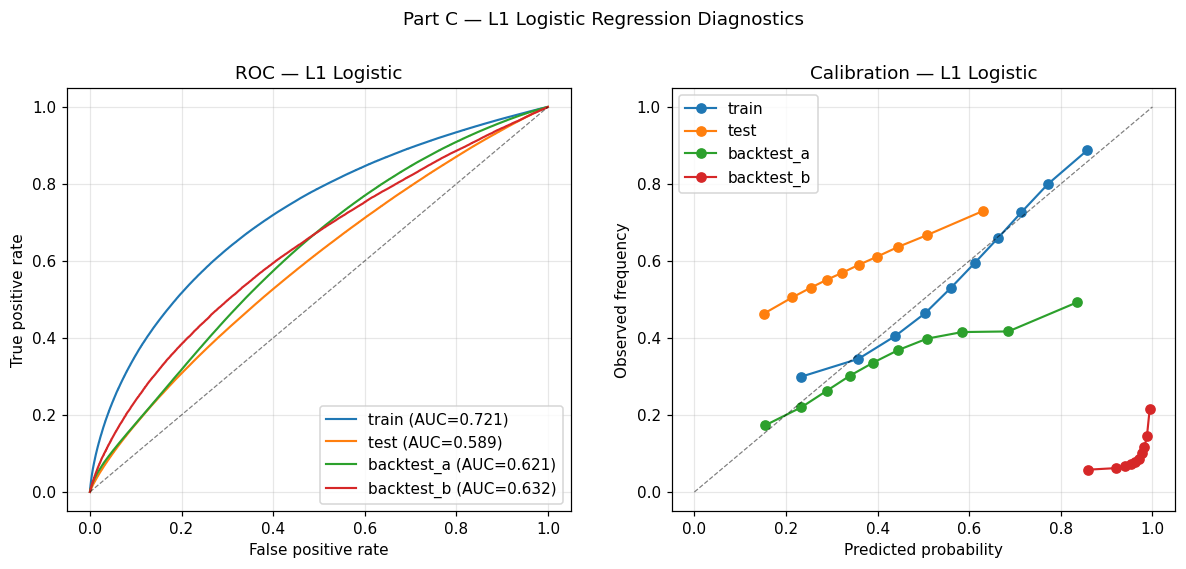

In [10]:
# Cell 13
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for name, _, y in eval_sets:
    p = preds_l1[name]
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, lw=1.4,
                 label=f"{name} (AUC={l1_metrics.loc[name, 'auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — L1 Logistic"); axes[0].grid(alpha=0.3); axes[0].legend()

# Calibration (reliability diagram, quantile bins)
for name, _, y in eval_sets:
    p = preds_l1[name]
    obs, pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    axes[1].plot(pred, obs, marker="o", lw=1.4, label=name)
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
axes[1].set_xlabel("Predicted probability"); axes[1].set_ylabel("Observed frequency")
axes[1].set_title("Calibration — L1 Logistic"); axes[1].grid(alpha=0.3); axes[1].legend()

fig.suptitle("Part C — L1 Logistic Regression Diagnostics", y=1.02)
fig.savefig(FIGURES_DIR / "partC_logistic_l1_diagnostics.png")
plt.show(); plt.close(fig)

## Model 2 — Random Forest

The "random forests" arm of Part C(i). Tree-based, scale-invariant, can capture
non-linear interactions (e.g., `orig_rate × vintage_year`). We'll see whether
this helps recover any signal the L1 logistic missed on the test set, or whether
the regime-confounding issue is fundamental and survives the switch to a more
flexible model class.

In [11]:
# Cell 16
# Eval sets — scaled for linear models, unscaled for trees (tree models are scale-invariant
# but unscaled features make feature importances directly interpretable).
eval_sets_scaled = [
    ("train",      X_tr_s, y_tr),
    ("test",       X_te_s, y_te),
    ("backtest_a", X_a_s,  y_a),
    ("backtest_b", X_b_s,  y_b),
]
eval_sets_unscaled = [
    ("train",      X_tr, y_tr),
    ("test",       X_te, y_te),
    ("backtest_a", X_a,  y_a),
    ("backtest_b", X_b,  y_b),
]

def record_model(model_name, model, eval_sets, master, preds_store):
    """Evaluate `model` on every split; append rows to `master`; cache predictions."""
    preds_store[model_name] = {}
    for split_name, X, y in eval_sets:
        p = model.predict_proba(X)[:, 1]
        preds_store[model_name][split_name] = p
        master.append({
            "model":    model_name,
            "split":    split_name,
            "n":        len(y),
            "auc":      roc_auc_score(y, p),
            "ap":       average_precision_score(y, p),
            "brier":    brier_score_loss(y, p),
            "pos_rate": float(y.mean()),
        })
    return master, preds_store

# Initialize / reset the master table and the prediction store. Re-add L1 logistic
# results so all models live in one place.
master_results = []
model_preds    = {}
master_results, model_preds = record_model(
    "L1 logistic", lr_l1, eval_sets_scaled, master_results, model_preds
)

print(pd.DataFrame(master_results)
      .set_index(["model", "split"])
      .to_string(float_format=lambda x: f"{x:.4f}"))

                              n    auc     ap  brier  pos_rate
model       split                                             
L1 logistic train       1619078 0.7213 0.7741 0.2107    0.5711
            test        4004821 0.5891 0.6635 0.2929    0.5853
            backtest_a  4274356 0.6211 0.4431 0.2388    0.3385
            backtest_b   637147 0.6323 0.1728 0.8194    0.1006


In [12]:
# Cell 17
from sklearn.ensemble import RandomForestClassifier

print("Fitting Random Forest (n_estimators=150, max_depth=14) — expect 3–8 minutes ...")
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators    = 150,
    max_depth       = 14,         # cap depth to prevent overfitting on 1.6M rows
    min_samples_leaf= 200,         # leaves can't be tiny — also bounds memory
    n_jobs          = -1,
    random_state    = RANDOM_SEED,
).fit(X_tr, y_tr)
print(f"  done in {time.time() - t0:.1f}s")

master_results, model_preds = record_model(
    "Random Forest", rf, eval_sets_unscaled, master_results, model_preds
)

print("\n" + "=" * 70)
print("Master results — L1 logistic vs Random Forest")
print("=" * 70)
print(pd.DataFrame(master_results)
      .set_index(["model", "split"])
      .to_string(float_format=lambda x: f"{x:.4f}"))

# Feature importances
print("\nRandom Forest feature importances:")
fi_rf = (pd.Series(rf.feature_importances_, index=feature_cols)
           .sort_values(ascending=False))
print(fi_rf.to_string(float_format=lambda x: f"{x:.4f}"))

Fitting Random Forest (n_estimators=150, max_depth=14) — expect 3–8 minutes ...
  done in 155.2s

Master results — L1 logistic vs Random Forest
                                n    auc     ap  brier  pos_rate
model         split                                             
L1 logistic   train       1619078 0.7213 0.7741 0.2107    0.5711
              test        4004821 0.5891 0.6635 0.2929    0.5853
              backtest_a  4274356 0.6211 0.4431 0.2388    0.3385
              backtest_b   637147 0.6323 0.1728 0.8194    0.1006
Random Forest train       1619078 0.7369 0.7880 0.2069    0.5711
              test        4004821 0.6205 0.6874 0.2477    0.5853
              backtest_a  4274356 0.7191 0.5735 0.2172    0.3385
              backtest_b   637147 0.5973 0.1428 0.3657    0.1006

Random Forest feature importances:
orig_rate                0.1655
orig_upb                 0.1503
log_cpi                  0.1129
vintage_year             0.0989
GS10                     0.0690
fico      

In [13]:
# Cell 17b
import joblib

MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(lr_l1,  MODELS_DIR / "partC_lr_l1_extended.joblib")
joblib.dump(rf,     MODELS_DIR / "partC_rf_extended.joblib")
joblib.dump(scaler, MODELS_DIR / "partC_scaler_extended.joblib")

print("Saved:")
for p in sorted(MODELS_DIR.glob("partC_*_extended.joblib")):
    print(f"  {p.relative_to(REPO_ROOT)}  ({p.stat().st_size/1e6:.1f} MB)")

Saved:
  models\partC_lr_l1_extended.joblib  (0.0 MB)
  models\partC_rf_extended.joblib  (27.9 MB)
  models\partC_scaler_extended.joblib  (0.0 MB)


## Models 3 & 4 — Gradient Boosting (LightGBM + XGBoost)

The "gradient boosting (XGBoost / LightGBM)" arm of Part C(i). Both are tree-based
like RF, but build trees sequentially correcting prior errors instead of in parallel
voting. Often the strongest tabular ML methods. Same data, same features, same
evaluation protocol — directly comparable.

In [14]:
# Cell 20
import lightgbm as lgb

print("Fitting LightGBM ...")
t0 = time.time()
lgbm = lgb.LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 63,         # 2^6 - 1; tree complexity cap
    max_depth         = -1,         # -1 = unlimited (num_leaves is the cap)
    min_child_samples = 200,
    colsample_bytree  = 0.8,
    subsample         = 0.8,
    subsample_freq    = 1,
    n_jobs            = -1,
    random_state      = RANDOM_SEED,
    verbose           = -1,
).fit(X_tr, y_tr)
print(f"  done in {time.time() - t0:.1f}s")

master_results, model_preds = record_model(
    "LightGBM", lgbm, eval_sets_unscaled, master_results, model_preds
)

print("\n" + "=" * 70); print("Master results so far"); print("=" * 70)
print(pd.DataFrame(master_results)
      .set_index(["model", "split"])
      .to_string(float_format=lambda x: f"{x:.4f}"))

fi_lgbm = (pd.Series(lgbm.feature_importances_, index=feature_cols)
             .sort_values(ascending=False))
print("\nLightGBM feature importances (split-count):")
print(fi_lgbm.to_string())

Fitting LightGBM ...
  done in 27.4s


c:\Users\loren\Desktop\IR Project\freddie-credit-30y-frm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\loren\Desktop\IR Project\freddie-credit-30y-frm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\loren\Desktop\IR Project\freddie-credit-30y-frm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\loren\Desktop\IR Project\freddie-credit-30y-frm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Master results so far
                                n    auc     ap  brier  pos_rate
model         split                                             
L1 logistic   train       1619078 0.7213 0.7741 0.2107    0.5711
              test        4004821 0.5891 0.6635 0.2929    0.5853
              backtest_a  4274356 0.6211 0.4431 0.2388    0.3385
              backtest_b   637147 0.6323 0.1728 0.8194    0.1006
Random Forest train       1619078 0.7369 0.7880 0.2069    0.5711
              test        4004821 0.6205 0.6874 0.2477    0.5853
              backtest_a  4274356 0.7191 0.5735 0.2172    0.3385
              backtest_b   637147 0.5973 0.1428 0.3657    0.1006
LightGBM      train       1619078 0.7634 0.8114 0.1949    0.5711
              test        4004821 0.6008 0.6778 0.2890    0.5853
              backtest_a  4274356 0.7073 0.5674 0.2038    0.3385
              backtest_b   637147 0.6314 0.1627 0.4764    0.1006

LightGBM feature importances (split-count):
orig_upb              

In [15]:
# Cell 21
import xgboost as xgb

print("Fitting XGBoost ...")
t0 = time.time()
xgbm = xgb.XGBClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    min_child_weight = 200,
    colsample_bytree = 0.8,
    subsample        = 0.8,
    tree_method      = "hist",      # fast histogram-based splitting
    n_jobs           = -1,
    random_state     = RANDOM_SEED,
    eval_metric      = "logloss",
).fit(X_tr, y_tr)
print(f"  done in {time.time() - t0:.1f}s")

master_results, model_preds = record_model(
    "XGBoost", xgbm, eval_sets_unscaled, master_results, model_preds
)

print("\n" + "=" * 70); print("Master results — all four ML models"); print("=" * 70)
print(pd.DataFrame(master_results)
      .set_index(["model", "split"])
      .to_string(float_format=lambda x: f"{x:.4f}"))

fi_xgb = (pd.Series(xgbm.feature_importances_, index=feature_cols)
            .sort_values(ascending=False))
print("\nXGBoost feature importances (gain):")
print(fi_xgb.to_string())

Fitting XGBoost ...
  done in 73.3s

Master results — all four ML models
                                n    auc     ap  brier  pos_rate
model         split                                             
L1 logistic   train       1619078 0.7213 0.7741 0.2107    0.5711
              test        4004821 0.5891 0.6635 0.2929    0.5853
              backtest_a  4274356 0.6211 0.4431 0.2388    0.3385
              backtest_b   637147 0.6323 0.1728 0.8194    0.1006
Random Forest train       1619078 0.7369 0.7880 0.2069    0.5711
              test        4004821 0.6205 0.6874 0.2477    0.5853
              backtest_a  4274356 0.7191 0.5735 0.2172    0.3385
              backtest_b   637147 0.5973 0.1428 0.3657    0.1006
LightGBM      train       1619078 0.7634 0.8114 0.1949    0.5711
              test        4004821 0.6008 0.6778 0.2890    0.5853
              backtest_a  4274356 0.7073 0.5674 0.2038    0.3385
              backtest_b   637147 0.6314 0.1627 0.4764    0.1006
XGBoost       tra

In [16]:
# Cell 22
joblib.dump(lgbm, MODELS_DIR / "partC_lgbm_extended.joblib")
joblib.dump(xgbm, MODELS_DIR / "partC_xgbm_extended.joblib")

print("Saved:")
for p in sorted(MODELS_DIR.glob("partC_*_extended.joblib")):
    print(f"  {p.relative_to(REPO_ROOT)}  ({p.stat().st_size/1e6:.1f} MB)")

Saved:
  models\partC_lgbm_extended.joblib  (3.6 MB)
  models\partC_lr_l1_extended.joblib  (0.0 MB)
  models\partC_rf_extended.joblib  (27.9 MB)
  models\partC_scaler_extended.joblib  (0.0 MB)
  models\partC_xgbm_extended.joblib  (1.7 MB)


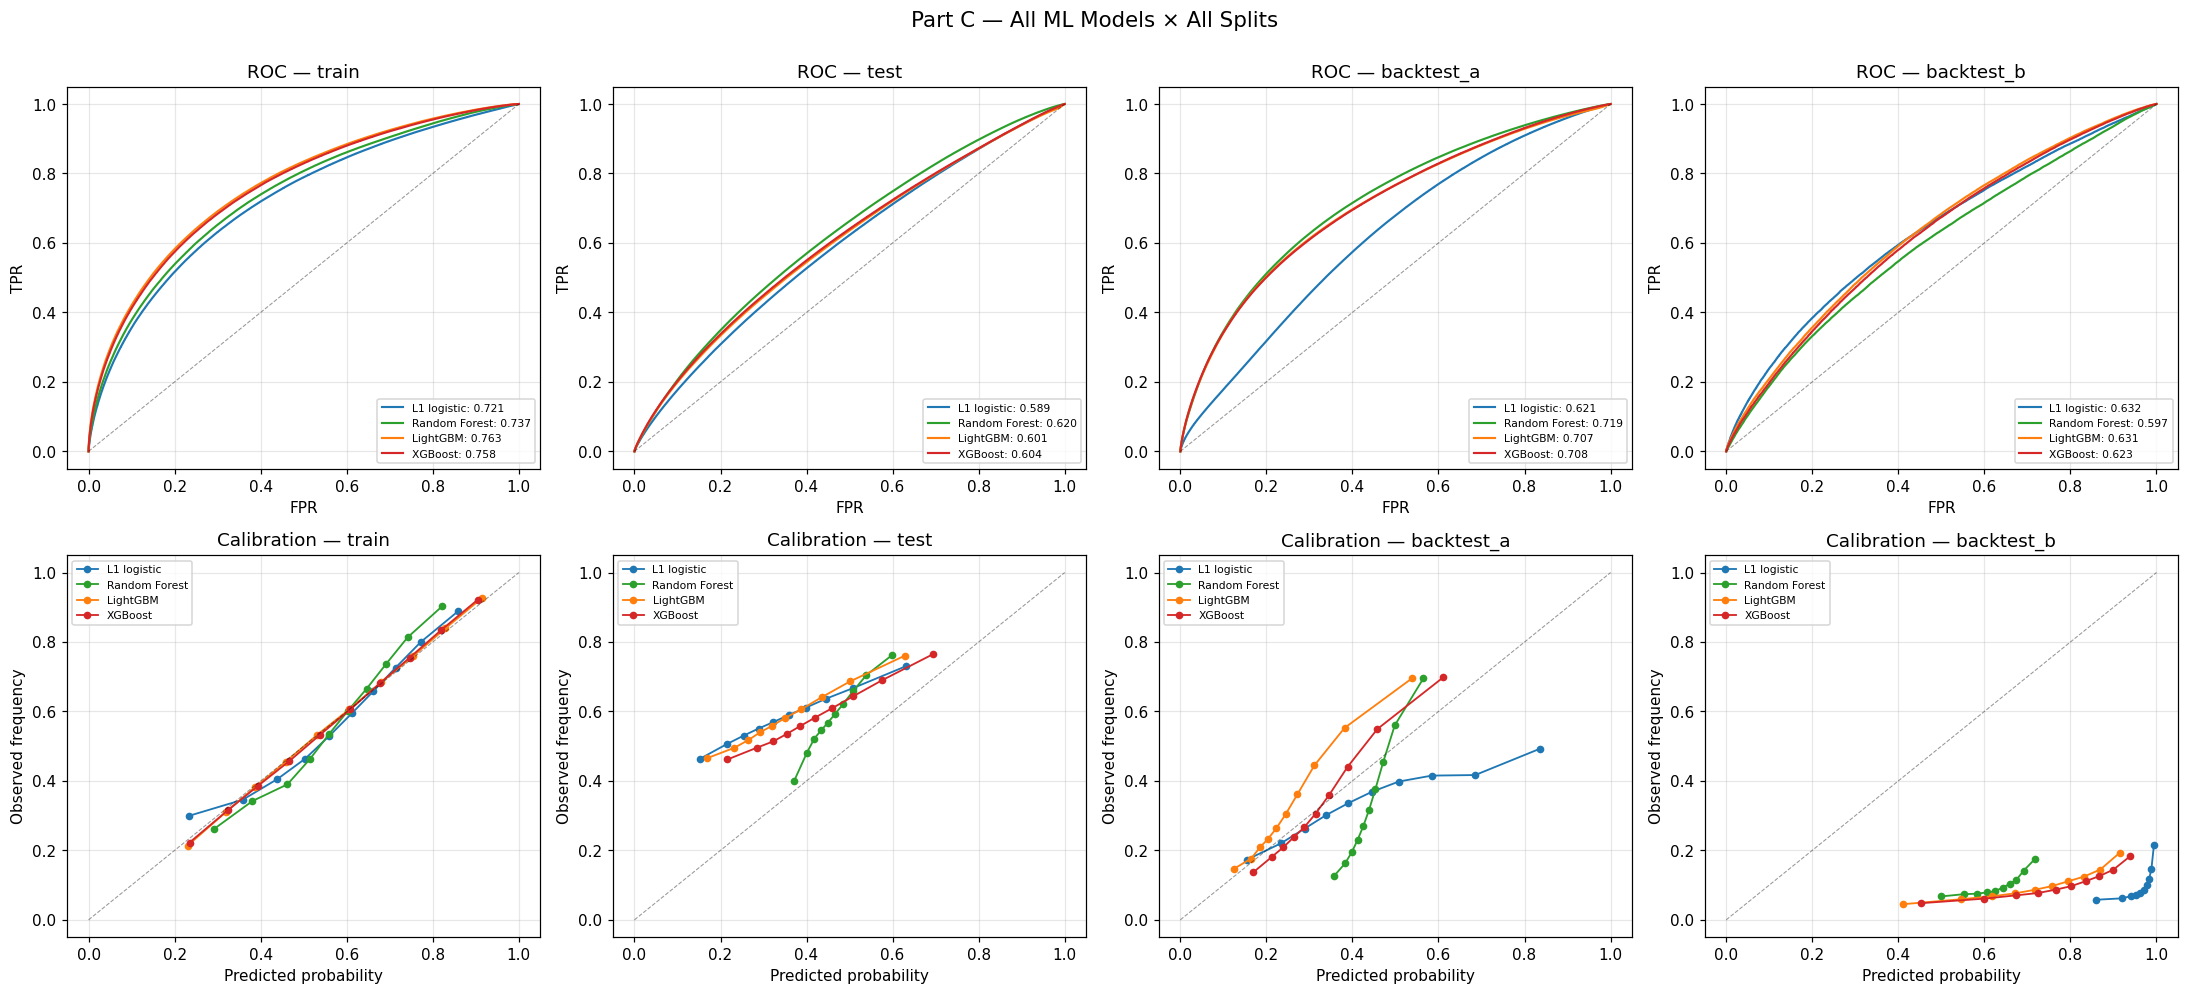

In [17]:
# Cell 23
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

split_iter = [("train", y_tr), ("test", y_te),
              ("backtest_a", y_a), ("backtest_b", y_b)]
ML_MODELS = ["L1 logistic", "Random Forest", "LightGBM", "XGBoost"]
colors = {"L1 logistic": "tab:blue", "Random Forest": "tab:green",
          "LightGBM": "tab:orange", "XGBoost": "tab:red"}

# Top row — ROC
for ax, (split_name, y) in zip(axes[0], split_iter):
    for m in ML_MODELS:
        p = model_preds[m][split_name]
        fpr, tpr, _ = roc_curve(y, p)
        ax.plot(fpr, tpr, lw=1.4, color=colors[m],
                label=f"{m}: {roc_auc_score(y, p):.3f}")
    ax.plot([0,1],[0,1], "k--", lw=0.7, alpha=0.4)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC — {split_name}")
    ax.legend(fontsize=7, loc="lower right"); ax.grid(alpha=0.3)

# Bottom row — Calibration
for ax, (split_name, y) in zip(axes[1], split_iter):
    for m in ML_MODELS:
        p = model_preds[m][split_name]
        obs, pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
        ax.plot(pred, obs, marker="o", markersize=4, lw=1.2,
                color=colors[m], label=m)
    ax.plot([0,1],[0,1], "k--", lw=0.7, alpha=0.4)
    ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed frequency")
    ax.set_title(f"Calibration — {split_name}")
    ax.legend(fontsize=7, loc="upper left"); ax.grid(alpha=0.3)

fig.suptitle("Part C — All ML Models × All Splits", y=1.00, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "partC_all_models_diagnostics.png")
plt.show(); plt.close(fig)

In [18]:
# Cell 24 — Hand-off parquets for Part B (Cox) and Part D (Deep Cox) teammates
# Each file has loan_seq_num + raw features (no one-hot, no scaling) + the
# duration / event / label columns. Teammates do their own preprocessing.
HANDOFF_DIR = REPO_ROOT / "handoff"
HANDOFF_DIR.mkdir(exist_ok=True)

cols_to_keep = ["loan_seq_num", DURATION_COL, EVENT_COL] + STATIC_FEATURES + [
    "GS10", "UNRATE", "rate_incentive_orig",
    "mort_treasury_spread", "log_hpi", "log_cpi",
]

handoff_specs = [
    ("team_train",      train,      LABEL_MAIN, cols_to_keep + [LABEL_MAIN]),
    ("team_test",       test,       LABEL_MAIN, cols_to_keep + [LABEL_MAIN]),
    ("team_backtest_a", backtest_a, LABEL_BT_A, cols_to_keep + [LABEL_BT_A]),
    ("team_backtest_b", backtest_b, LABEL_BT_B, cols_to_keep + [LABEL_BT_B]),
]

for name, df, lbl, cols in handoff_specs:
    out_path = HANDOFF_DIR / f"{name}.parquet"
    df[cols].to_parquet(out_path, index=False)
    print(f"  {out_path.relative_to(REPO_ROOT)}  "
          f"n={len(df):,}  pos_rate={df[lbl].mean():.3f}  "
          f"size={out_path.stat().st_size/1e6:.1f} MB")

print(f"\nAll four files saved to {HANDOFF_DIR}")
print("Each contains raw features + macro + label for the same loans your ML sees.")
print("Teammates: do your own one-hot / scaling; just use the listed split files.")

  handoff\team_train.parquet  n=1,951,750  pos_rate=0.541  size=46.8 MB
  handoff\team_test.parquet  n=4,199,495  pos_rate=0.577  size=67.8 MB
  handoff\team_backtest_a.parquet  n=4,276,019  pos_rate=0.339  size=68.2 MB
  handoff\team_backtest_b.parquet  n=637,366  pos_rate=0.101  size=10.5 MB

All four files saved to c:\Users\loren\Desktop\IR Project\freddie-credit-30y-frm\handoff
Each contains raw features + macro + label for the same loans your ML sees.
Teammates: do your own one-hot / scaling; just use the listed split files.


In [19]:
for split_name, ids in [("test", id_te), ("backtest_a", id_a), ("backtest_b", id_b)]:
    df_out = pd.DataFrame({"loan_seq_num": ids})
    for model_name in ML_MODELS:
        col = f"{model_name.lower().replace(' ', '_')}_prob"
        df_out[col] = model_preds[model_name][split_name]
    df_out.to_csv(MODELS_DIR / f"partC_ml_predictions_{split_name}.csv", index=False)
print("Saved predictions for all 4 ML models on 3 evaluation splits.")

Saved predictions for all 4 ML models on 3 evaluation splits.
